In [1]:
import os
from glob import glob
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import re
import matplotlib.font_manager as font_manager

In [2]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

In [3]:
book_df = pd.read_csv("book_sample_data.csv")

In [4]:
CLEANR = re.compile('<.*?>|&([a-z0-9]+|#[0-9]{1,6}|#x[0-9a-f]{1,6});')
def cleanhtml(raw_html):
    cleantext = re.sub(CLEANR, '', raw_html)
    
    return cleantext
    
def cleantext(raw_text):
    cleantext = re.sub(r'[^\w]', ' ', raw_text)
    cleantext = re.sub(' +', ' ', cleantext)
    return cleantext

In [7]:
import re
# string = headline_df['description'][0]
# cleanString = re.sub('\W+',' ', string )

In [8]:
book_df['new_description'] = book_df['description'].apply(cleantext)

In [10]:
sentences = book_df.new_description.tolist()
embeddings = model.encode(sentences, show_progress_bar=True)
book_df['embedding'] = embeddings.tolist()

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

In [11]:
from scipy.stats import pearsonr
from sklearn.manifold import TSNE, MDS
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances

In [12]:
mds = MDS(n_components=2, metric=True, random_state=345)
z = mds.fit_transform(embeddings)

In [13]:
distance_embed = euclidean_distances(embeddings)
distance_grid = euclidean_distances(z)
x1 = distance_embed[np.triu_indices(225,1)]
x2 = distance_grid[np.triu_indices(225,1)]
print(pearsonr(x1, x2))

PearsonRResult(statistic=0.5857093985656221, pvalue=0.0)


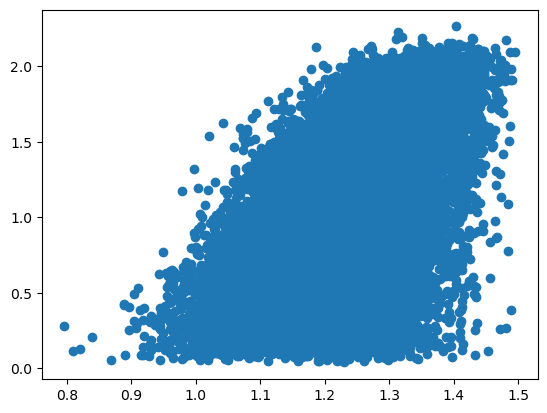

In [14]:
plt.scatter(distance_embed[np.triu_indices(225,1)], distance_grid[np.triu_indices(225,1)])

In [17]:
genre_color = []
indexs = []
isbn_list = []
for i in range(15):
    index = np.argsort(z[:,1])[(15*i):(15*i+15)]
    index = index[np.argsort(z[index,0])]
    indexs.append(index)
    genre_color.append(book_df["selected_genre"].to_numpy()[index])
    
genre_color = np.concatenate(genre_color)
indexs = np.concatenate(indexs)

M, N = 15, 15

x = np.linspace(-7,7,M)
y = np.linspace(-7,7,N)
X,Y = np.meshgrid(x,y)

positions = np.vstack([Y.ravel(), X.ravel()])
positions = positions[::-1]
grid = pd.DataFrame(positions.T)
grid.columns = ["x", "y"]

grid["color"] = genre_color
grid["book_index"] = indexs
grid["embeddings"] = embeddings[indexs].tolist()
grid["mds"] = z[indexs].tolist()
grid["isbn"] = book_df.isbn[indexs].tolist()
grid.index = grid.isbn.tolist()
grid = grid.merge(book_df[["isbn", "description"]], how="left", on="isbn")
grid

,x,y,color,book_index,embeddings,mds,isbn,description
0,-7.0,-7.0,Science Fiction,4,"[-0.035935595631599426, 0.06197577714920044, 0...","[-0.7137714960738535, -0.9004126172758066]",1480597333,"In the twentieth century Earth sent probes, tr..."
1,-6.0,-7.0,Science Fiction,99,"[-0.012506712228059769, 0.0008930209442041814,...","[-0.5971301432626743, -0.892162310285897]",1548258261,"The Galaxy is a Dumpster Fire A hot, stinking,..."
2,-5.0,-7.0,Historical Fiction,119,"[0.023538360372185707, 0.014585901983082294, -...","[-0.3699069550953278, -0.9449906581444997]",0999120808,"""Is it better to be a bad man and accomplish g..."
3,-4.0,-7.0,Historical Fiction,117,"[-0.10087019950151443, 0.020130902528762817, 0...","[-0.36907916405490626, -1.0693397044567103]",1530641217,"Burmese War, 1852. Unable to join the famous R..."
4,-3.0,-7.0,Historical Fiction,111,"[-0.006053153891116381, 0.0045183319598436356,...","[-0.22420080106085602, -0.9473660975343393]",1490319913,Over 14 days at the heart of the Battle of Bri...
...,...,...,...,...,...,...,...,...
220,3.0,7.0,Mystery,194,"[-0.06557729095220566, 0.0021038628183305264, ...","[0.2189193658824496, 0.9837182877007474]",1500386022,Pretty please with spaghetti on top? Andy Buck...
221,4.0,7.0,Mystery,190,"[0.045192867517471313, -0.015335571020841599, ...","[0.27925928160105346, 0.903330785170149]",0994527276,Gemma ditches her high-flying job and returns ...
222,5.0,7.0,Romance,164,"[-0.04157397150993347, -0.042087309062480927, ...","[0.28751576789255984, 0.9532092245256178]",1530560020,Do Squire and Kelly have enough patience and f...
223,6.0,7.0,Romance,38,"[-0.009882464073598385, -0.08653517812490463, ...","[0.4886361013606919, 0.8417378831996545]",0991457927,When Val Jensen gets dumped for her decision t...


In [ ]:
grid.to_csv("grid_data.csv")

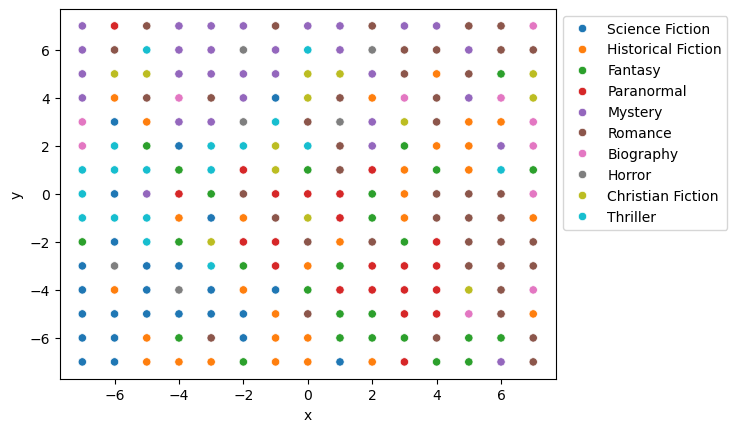

In [18]:
sns.scatterplot(data = grid, x="x", y="y", hue="color")
plt.legend(bbox_to_anchor=(1, 1))   
plt.show()